# MCMC diagnostics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/mcmc_diagnostics.ipynb)

## LEARNING OUTCOMES
- Understand and implement different MCMC diagnostics for assessing convergence and mixing of MCMC chains
- Learn to diagnose what is wrong from MCMC output and know what to change to fix it

## Introduction
Two "issues" with MCMC are that:
- it can take a long time for the chain to reach the high posterior density part of the parameter space and produce samples from the posterior distribution (which relates to  the _convergence_ of the MCMC chain to its stationary distribution)
- it does not produce independent samples from the posterior distribution (which relates to what we call the _mixing_ of the MCMC chain)

What we would like is for the chain to have converged, so that we're sampling from the posterior distribution, and for the samples to be as close to independent as possible. When the samples are close to uncorrelated, we say the chain is _mixing well_. To achieve this we need to tune the proposal variance for the jumps at each iteration, so that the parameter space is explored as efficiently as possible (i.e. we make as big jumps as possible without jumping out of the high posterior density region too often).

## Visual diagnostics

The three most fundamental visual diagnostic methods for assessing the quality of an MCMC chain are _trace plots_, _autocorrelation plots_ (ACF plots), and _posterior predictive plots_.  We will examine each in turn.

### Trace plots
The first visual diagnostic we can use to check if the chain is mixing well are trace plots.

- stepped trace plots suggest the proposal variance is too large (most proposals are jumping out of the high probability density region and hence being rejected)
- meandering/snaking trace plots suggest high autocorrelation between samples and proposal variance is too small

E.g. if we rerun the random walk Metropolis algorithm above with a larger proposal variance:

In [1]:
from gemlib.distributions import DiscreteTimeStateTransitionModel
from gemlib.mcmc import mcmc, rwmh
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow_probability.substrates.jax as tfp

DTYPE=np.float32
sns_c = sns.color_palette(palette = "Dark2")
tfd = tfp.distributions

%matplotlib inline

In [2]:
incidence_matrix = np.array(
    [ #  SI  IR
        [-1,  0],  # S
        [ 1, -1],  # I
        [ 0,  1],  # R
    ],
    dtype=DTYPE
)

popsize = 1000

initial_state = np.array([[999, 1, 0],
                          ]).astype(DTYPE)

def sir_model(beta, gamma):
    
    def si_rate(t, state):
        return beta * state[:, 1] / state.sum(axis=-1)
    
    def ir_rate(t, state):
        return gamma
    
    return DiscreteTimeStateTransitionModel(transition_rate_fn=[si_rate, ir_rate],
                                            incidence_matrix=incidence_matrix,
                                            initial_state=initial_state,
                                            initial_step=0,
                                            time_delta=1.0,
                                            num_steps=100,
                                            name="sir")



In [3]:
@tfd.JointDistributionCoroutineAutoBatched
def model():
    # Priors
    beta = yield tfd.Gamma(
            concentration=DTYPE(1.0), rate=DTYPE(5.0), name="beta"
    )
    
    gamma = yield tfd.Gamma(
            concentration=DTYPE(1.0), rate=DTYPE(0.5), name="gamma"
    )

    yield sir_model(beta, gamma)

In [4]:
sir = sir_model(beta=0.3, gamma=0.1)
sir_sim = sir.sample(seed=jax.random.key(1))

conditioned_model = model.experimental_pin(sir=sir_sim)

In [5]:
# construct RWM kernel
kernel_large = rwmh(scale=0.1)

samples_large, info_large = mcmc(
    num_samples=10000,
    sampling_algorithm=kernel_large,
    target_density_fn=conditioned_model.log_prob,
    initial_position=conditioned_model.sample_unpinned(seed=jax.random.key(42)),
    seed=jax.random.key(1),
)

and plot the trace plots

In [6]:
def trace_plot(samples):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # if not isinstance(samples, list):
    #     samples = [samples]
    if np.ndim(samples.beta)==1:
        # beta
        ax[0].plot(samples.beta, linewidth=1)
        # gamma
        ax[1].plot(samples.gamma, linewidth=1)
    else:
        # trace plots for parameters
        for i in range(num_chains):
            # beta
            ax[0].plot(samples.beta[:,i], color=sns_c[i], linewidth=1, alpha=0.3, label = 'Chain '+str(i))
            # gamma
            ax[1].plot(samples.gamma[:,i], color=sns_c[i], linewidth=1, alpha=0.3, label = 'Chain '+str(i))
        # legend
        handles, labels = ax[1].get_legend_handles_labels()
        fig.legend(handles, labels, loc=5, bbox_to_anchor=(1.2, 0.5), title="Chain")

    # subtitles
    ax[0].set_title('Trace plot of beta')
    ax[1].set_title('Trace plot of gamma')

    # axis limits
    # ax[0].set_ylim(0., 0.4)
    ax[1].set_ylim(0., 0.2)

    # true value lines
    ax[0].hlines(xmin=0, xmax=samples.beta.shape[0], y=0.3, color="red")
    ax[1].hlines(xmin=0, xmax=samples.beta.shape[0], y=0.1, color="red")

    # plot level axis labels
    ax[0].set_xlabel("Iteration")
    ax[1].set_xlabel('Iteration')
    fig.text(0.04, 0.5, 'Parameter Value', va='center', rotation='vertical')

    plt.show()

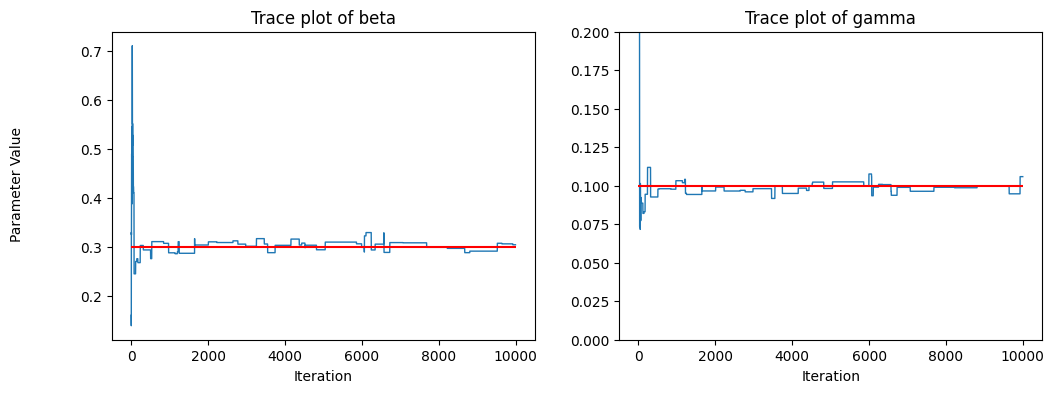

In [7]:
trace_plot(samples_large)

we see that they look very stepped.

````{exercise}
:label: ex9.1

Rerun the RWM with a smaller proposal variance, e.g. `scale=0.001`, and plot the traces for the parameters. What do you observe?

```{tip}
First instantiate the RWMH kernel using `rwmh`, then run the MCMC using `mcmc`, and finally plot the traceplots.
```

````

````{solution-start} ex9.1
:class: dropdown
````

In [8]:
# construct RWM kernel
kernel_small = rwmh(scale=0.001)

samples_small, info_small = mcmc(
    num_samples=10000,
    sampling_algorithm=kernel_small,
    target_density_fn=conditioned_model.log_prob,
    initial_position=conditioned_model.sample_unpinned(seed=jax.random.key(42)),
    seed=jax.random.key(3),
)

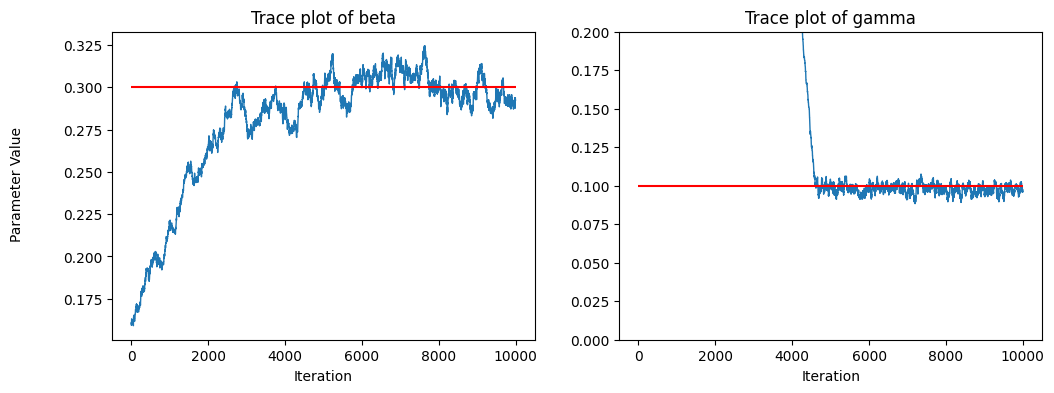

In [9]:
trace_plot(samples_small)

we see that the chain both takes longer to converge and once converged wanders about the true value.



If the proposal variance is set correctly the trace plot should oscillate up and down quickly and look like a "hairy caterpillar":

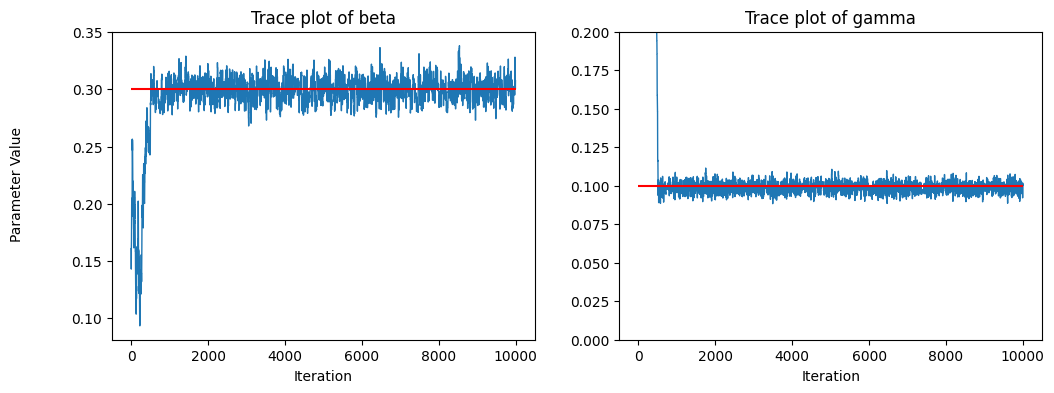

In [10]:
kernel = rwmh(scale=0.01)

samples, info = mcmc(
    num_samples = 10000,
    sampling_algorithm=kernel,
    target_density_fn=conditioned_model.log_prob,
    initial_position = conditioned_model.sample_unpinned(seed=jax.random.key(42)),
    seed = jax.random.key(1),
)
trace_plot(samples)

````{solution-end}
````

### ACF plots

Autocorrelation function (ACF) plots can also tell us how well the chain is mixing.

They show the correlation between values in the MCMC chain at different lags. The shaded region on the plot shows the 95% CI for the autocorrelation under the null hypothesis that there is no autocorrelation beyond the corresponding lag, i.e. where the autocorrelation can be considered statistically significant if it falls outside this region.

If the autocorrelation decreases quickly into the shaded region with increasing lags, the chain is mixing well.

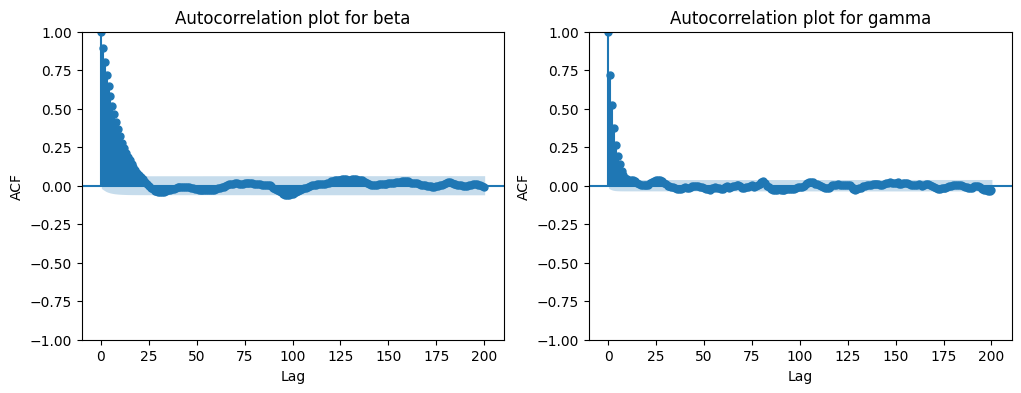

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

def acf_plot(samples):
    # acf plots for parameters
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    # beta
    _ = plot_acf(samples.beta[1000:], ax=ax[0], lags=200)
    ax[0].set_title('Autocorrelation plot for beta')
    ax[0].set_xlabel('Lag')
    ax[0].set_ylabel('ACF')
    # gamma
    _ = plot_acf(samples.gamma[1000:], ax=ax[1], lags=200)
    ax[1].set_title('Autocorrelation plot for gamma')
    ax[1].set_xlabel('Lag')
    ax[1].set_ylabel('ACF')

acf_plot(samples)

These plots tell us that approximately every 30th sample in the chain is independent with a proposal standard deviation of 0.01.

We can see that the samples in the chain with the smaller proposal variance are much more strongly autocorrelated:

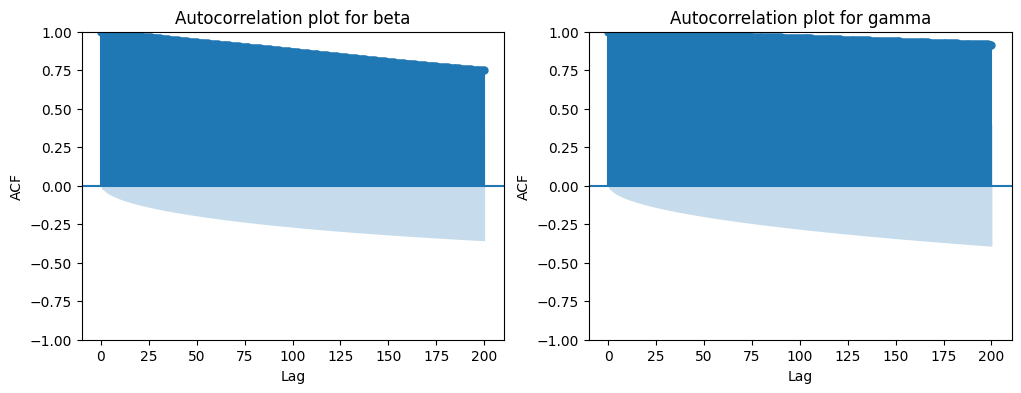

In [12]:
acf_plot(samples_small)

```{exercise}
:label: ex9.2

Plot the ACF plots for the chain with the larger proposal variance. What do you see? What does this suggest?
```

````{solution-start} ex9.2
:class: dropdown
````

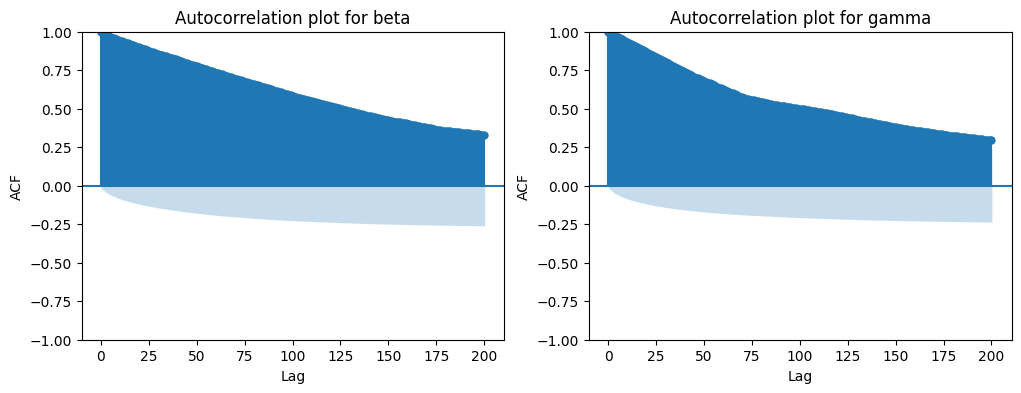

In [13]:
acf_plot(samples_large)

The autocorrelation for $\gamma$ reduces much more quickly than that for $\beta$ and faster than with the original proposal variance, suggesting that the smaller proposal variance for $\gamma$ (with `scale=0.001`) is better than the original proposal variance (with `scale=0.01`).

````{solution-end}
````

### Multiple chains
To be confident that the chain has converged it is a good idea to:
- run multiple chains started from different points in the parameter space
- check that they all end up around the same value

Let's run 4 different chains from different starting points with different random number seeds:

In [14]:
num_chains = 4
initial_position = conditioned_model.sample_unpinned(
    num_chains, seed=jax.random.key(1)
)

In [15]:
chains_samples, chains_info = mcmc(
        num_samples=10000,
        sampling_algorithm=kernel,
        target_density_fn=conditioned_model.log_prob,
        initial_position=initial_position,
        seed=jax.random.key(42),
)

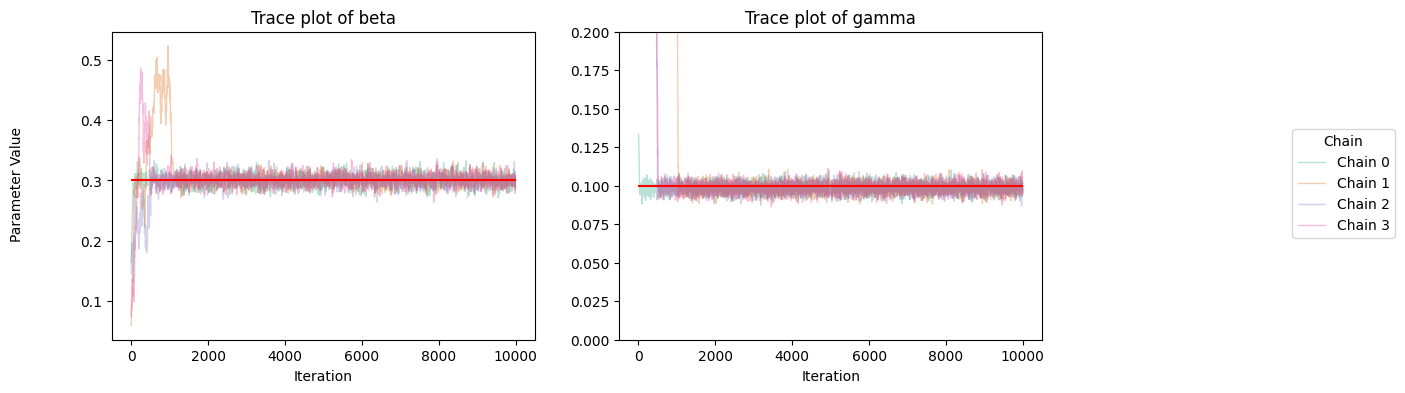

In [16]:
trace_plot(chains_samples)

We can see that all the chains converge to the same values.

### Posterior predictive checks

We pick some posterior samples for the parameters with which to simulate the model

In [17]:
samples_sim = (samples.beta[1000:10000:30],samples.gamma[1000:10000:30])

and repeat each sample 10 times, so that we'll get 10 simulations for each sample

In [18]:
beta_samples = jnp.repeat(samples_sim[0],10)
gamma_samples = jnp.repeat(samples_sim[1],10)

then run the simulations

In [19]:
posterior_sim = model.sample(
    beta=beta_samples, gamma=gamma_samples, seed=jax.random.key(2)
)

In [20]:
# Do it the manual way
@jax.vmap
def postsim(beta, gamma, key):
    model = sir_model(beta, gamma)
    return model.sample(seed=key)

posterior_sim1 = postsim(beta_samples, gamma_samples, jax.random.split(jax.random.key(2), num=beta_samples.shape[0]))

This gives us a tensor the size of whose first dimension is the number of $(\beta,\gamma)$ samples, and the size whose remaining dimensions are those of the transition events tensor.

In [21]:
posterior_sim.sir.shape

(3000, 100, 1, 2)

In [22]:
posterior_sim1.shape

(3000, 100, 1, 2)

We convert this to the state tensor as previously

In [27]:
posterior_sim_state = sir.compute_state(posterior_sim.sir)
posterior_sim_state1 = sir.compute_state(posterior_sim1)
sir_sim_state = sir.compute_state(sir_sim)

We can find the median and 95% credible interval of the simulations using the `np.quantile` function:

In [28]:
q_posterior_sim_state = np.quantile(posterior_sim_state, [0.025,0.5,0.975], axis=0)
q_posterior_sim_state1 = np.quantile(posterior_sim_state1, [0.025,0.5,0.975], axis=0)

In [29]:
q_posterior_sim_state.shape

(3, 100, 1, 3)

and plot the output

/tmp/ipykernel_561792/2281082913.py:13: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(handles=plot_handles,


Text(0, 0.5, 'Population')

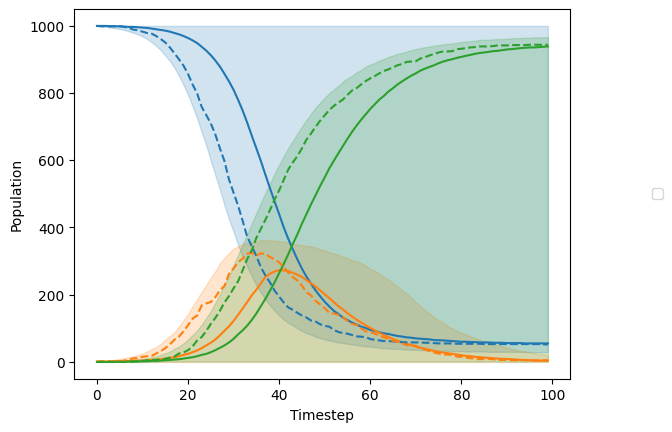

In [30]:
x = range(q_posterior_sim_state.shape[1])
S_line = plt.plot(q_posterior_sim_state1[1,:,0,0], color='#1f77b4')
plt.fill_between(x,q_posterior_sim_state1[0,:,0,0], q_posterior_sim_state1[2,:,0,0], alpha=0.2, color='#1f77b4')
I_line = plt.plot(q_posterior_sim_state1[1,:,0,1], color='#ff7f0e')
plt.fill_between(x,q_posterior_sim_state1[0,:,0,1], q_posterior_sim_state1[2,:,0,1], alpha=0.2, color='#ff7f0e')
R_line = plt.plot(q_posterior_sim_state1[1,:,0,2], color='#2ca02c')
plt.fill_between(x,q_posterior_sim_state1[0,:,0,2], q_posterior_sim_state1[2,:,0,2], alpha=0.2, color='#2ca02c')
plt.plot(sir_sim_state[:, 0, :], linestyle="dashed")

plot_handles = [S_line, I_line, R_line]

# Generate legend using handles and labels
plt.legend(handles=plot_handles,
           labels=["S", "I", "R"],
           loc=5, bbox_to_anchor=(1.2,0.5))

plt.xlabel("Timestep")
plt.ylabel("Population")

```{exercise}
:label: ex9.3

Why do you think the upper bound of the 95% credible interval for the number of susceptibles is the total population size?
```

```{solution} ex9.3
:class: dropdown

Remember that a stochastic epidemic has a non-zero probability of dying out at the first generation of infection.
```

## Numerical diagnostics

There are also a number of numerical diagnostics that we should check before accepting our MCMC chain as, in some sense, "good".

### Acceptance rate
We can check the acceptance rate to make sure it's not too high but also not too low, so that the chain is efficiently exploring the parameter space. There is some theory that tells us that the optimal acceptance rate for mixing of the random walk Metropolis algorithm in 1D is 0.44 and in multiple dimensions when the posterior distribution is approximately multivariate normal is 0.234 [[1](https://doi.org/10.1214/aoap/1034625254),[2](https://doi.org/10.3150/08-BEJ176)].

For the original MCMC run we get:

In [31]:
acc_rate = np.mean(info.is_accepted)
acc_rate

Array(0.2958, dtype=float32)

while for the runs with larger and smaller proposal variances we get much lower and higher acceptance rates respectively:

In [32]:
acc_rate_large = np.mean(info_large.is_accepted)
print(acc_rate_large)
acc_rate_small = np.mean(info_small.is_accepted)
print(acc_rate_small)

0.0072
0.7377


### Effective sample size
Effective sample size (ESS) is the number of independent samples that the autocorrelated MCMC samples are equivalent to.

For a quantity estimated from the posterior distribution, it is the number of independent identically distributed samples that would lead to the same variance in this quantity as that obtained from the chain.

Formally it is defined as:

$$
\mathrm{ESS} = \frac{n}{1+2\sum_{k=1}^\infty \rho_k}
$$

where $n$ is the number of MCMC iterations and $\rho_k$ is the lag-$k$ autocorrelation for the samples in the chain. If there were no autocorrelation between the samples ($\rho_k=0, \forall k$) then the ESS would be equal to the number of iterations.

We are looking for as high ESS as possible.

Calculating ESS for the original chain we get:

In [33]:
ess = jax.tree.map(lambda x: tfp.mcmc.effective_sample_size(x[1000:]), samples)
ess

StructTuple(
  beta=Array(564.29706, dtype=float32),
  gamma=Array(1316.7601, dtype=float32)
)

and for the runs with larger and smaller proposal variance we get mostly lower values:

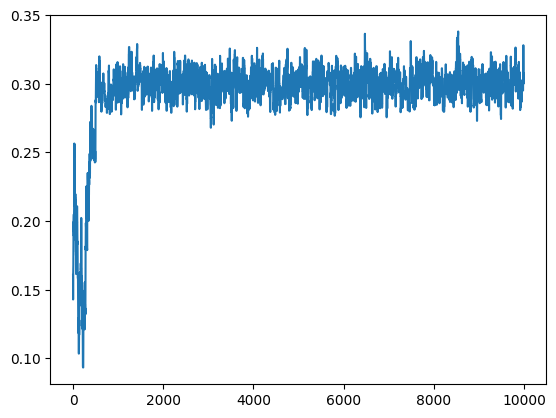

In [34]:
plt.plot(samples.beta)

In [35]:
ess_large = tfp.mcmc.effective_sample_size(samples_large)
print(ess_large)

StructTuple(
  beta=Array(179.93242, dtype=float32),
  gamma=Array(433.88046, dtype=float32)
)


The fact that the ESS for $\gamma$ for the run with the larger proposal variance is larger than for the original run suggests that we could perhaps improve the mixing of the chain by using different proposal variances for $\beta$ and $\gamma$, rather than the same proposal variance for both as above. We will come back to this idea below.

```{exercise}
:label: ex9.4

Calculate the ESS for the MCMC run with the smaller proposal variance. What do you find?
```

````{solution-start} ex9.4
````

In [36]:
ess_small = tfp.mcmc.effective_sample_size(samples_small)
print(ess_small)

StructTuple(
  beta=Array(4.65045, dtype=float32),
  gamma=Array(3.4065669, dtype=float32)
)


````{solution-end}
````

### Gelman-Rubin convergence diagnostic
If we have output from multiple chains, we can assess convergence numerically as well as visually, using the Gelman-Rubin diagnostic. This compares the variance of samples between chains to that of the samples within each chain. The idea being that if the chains have converged, these should be approximately equal.

It is given by:

$$
\hat{R}=\frac{\frac{n-1}{n}W+\frac{1}{n}B}{W}
$$

where $B$ is the variance between the means of the chains, and $W$ is the average of the within-chain variances.

Typically, $\hat{R} < 1.1$ is taken to indicate convergence of the chains.

For the chains with the original proposal variances, the $\hat{R}$ values for $\beta$ and $\gamma$ are:

In [37]:
rhat = tfp.mcmc.diagnostic.potential_scale_reduction(
    chains_samples, independent_chain_ndims=1)
rhat

StructTuple(
  beta=Array(1.0375419, dtype=float32),
  gamma=Array(1.0639988, dtype=float32)
)

i.e. are both $< 1.1$ sugggesting that the chain has converged.

## Adaptive MCMC

Having to manually tune the proposal variance is annoying and becomes particularly difficult as the dimension of the parameter space gets larger. For epidemic models, there is also often strong correlation between the parameters we are trying to estimate, such as the infection and recovery rates, $\beta$ and $\gamma$, for the SIR model if our data really only gives us information about $R_0=\beta/\gamma$ (i.e. their ratio). Updating each parameter using a separate M-H step or jointly with a symmetric proposal distribution will perform poorly in this context, as lots of the proposals will fall outside of the high-posterior-density region of the parameter space and hence be rejected. Really we want to do a block update that reflects correlations between the parameters.

The best proposal distribution would be the posterior distribution, but this is what we are trying to estimate! We can perform trial MCMC runs with different proposal variances to get an idea of what proposal variances give good mixing, along the lines of the above. To estimate the covariance of the posterior distribution, we can calculate the empirical covariance matrix:

In [38]:
cov_samples = np.cov(samples)
cov_samples

array([[ 0.00073264, -0.00492984],
       [-0.00492984,  0.04784396]])

The diagonal elements give us an idea of the variance of the posterior for each parameter, while the off-diagonal elements tell us about the covariance of the parameters in the posterior. Here we can see that there is positive correlation between $\beta$ and $\gamma$.

There is some theory [[1](https://doi.org/10.1214/aoap/1034625254),[3](https://doi.org/10.1214/ss/1015346320)] that says that the optimal proposal distribution for a random-walk Metropolis algorithm in large dimensions is:

$$
N\left(\theta,\frac{2.38^2}{d}\Sigma\right)
$$

where $\Sigma$ is the covariance matrix of the posterior distribution $\pi(\theta|y)$, and $d$ is the dimension of $\theta$.

Ideally, we would adapt the proposal covariance on the fly while the chain is running, rather than having to do trial runs beforehand. We can do this via the adaptive random walk Metropolis Hastings (RWMH) algorithm in `gemlib`. This implements a version of Algorithm 6 (a block adaptive random walk) from [[4]](https://doi.org/10.1214/10-STS327). This algorithm makes proposals of the form:

$$
\theta'\sim\begin{cases}
N(\theta,m_k^2\Sigma_k) \;\text{with probability}\;1-\delta\\
N(\theta,\lambda_0^2I/d)\;\text{with probability}\;\delta
\end{cases}
$$

where $\Sigma_k$ is the running estimate of the covariance matrix at the $k$th iteration; $\delta$ is the probability of drawing from the non-adaptive part of the kernel, typically chosen to be a small value such as $0.05$; and $m_k$ is a scaling factor for the covariance of the proposal, initialised as $m_0=2.38/\sqrt{d}$ and updated as follows:

\begin{align*}
m_{k+1}&=m_k \;\text{if iteration $k$ was non-adaptive, otherwise} \\
m_{k+1}&=\begin{cases}
m_k-\Delta/\sqrt{k} &\text{if the proposal was rejected}\\
m_k+2.3\Delta/\sqrt{k} &\text{if the proposal was accepted}
\end{cases}
\end{align*}

where $\Delta=m_0/100$. $\lambda_0$ is the scaling parameter for the non-adaptive proposals.

The idea is that if the acceptance rate is too low/high we shrink/expand the scale of the proposal distribution and adapt the shape of the proposal distribution according to the running estimate of the posterior covariance matrix to try to achieve the desired acceptance rate. The adaptation has to satisfy a condition called _diminishing adaptation_, which means that the amount of adaptation becomes negligible as the number of iterations becomes large, otherwise the chain will not converge to the correct stationary distribution. This is why the changes in the covariance scaling factor $m_k$ are scaled with $1/\sqrt{k}$.

Lets run the adaptive random walk algorithm on our SIR example from above. First we need to load the MCMC and adaptive random walk Metropolis-Hastings samplers from the `gemlib` library:

In [ ]:
from gemlib.mcmc import mcmc
from gemlib.mcmc import adaptive_rwmh

We set an initial position for the chain by sampling from the conditioned model

In [ ]:
initial_position = conditioned_model.sample_unpinned(seed=jax.random.key(8))

and initialise a MCMC kernel for the adaptive random walk updates

In [ ]:
kernel_adaptive = adaptive_rwmh(initial_scale=None)

Then run the MCMC

In [ ]:
samples_adaptive, info_adaptive = jax.jit(
    lambda: mcmc(num_samples=10000,
                 sampling_algorithm=kernel_adaptive,
                 target_density_fn=conditioned_model.log_prob,
                 initial_position=initial_position,
                 seed=jax.random.key(2),
                )
)()

and plot the output

In [ ]:
trace_plot(samples_adaptive)

This gives an acceptance rate $\approx 0.3$, as expected from [[4]](https://doi.org/10.1214/10-STS327):

In [ ]:
acc_rate_adaptive = np.mean(info_adaptive.is_accepted)
acc_rate_adaptive

and if we compute the ESS, we find that it is much higher for both $\beta$ and $\gamma$ than for any of the fixed proposal variance runs:

In [ ]:
ess_adaptive = tfp.mcmc.effective_sample_size(samples_adaptive)
print(ess_adaptive)